# 2. XGBoost — Irrigation Need (Multiclass)

Primer modelo: XGBClassifier multiclase con todas las variables.

1. Preprocesamiento con OrdinalEncoder
2. Modelo base con Cross-Validation (Accuracy + Log-Loss)
3. Tuning con RandomizedSearchCV
4. Validación del modelo tuned
5. Feature importance
6. Predicciones + envío a Kaggle

**Dataset:** Playground Series S6E4 | **Clases:** Low / Medium / High | **Métrica:** Accuracy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Librerías cargadas")

Librerías cargadas


## 1. Carga y Preprocesamiento

In [2]:
train_raw  = pd.read_csv("../data/train.csv")
test_raw   = pd.read_csv("../data/test.csv")
sample_sub = pd.read_csv("../data/sample_submission.csv")

print(f"Train:  {train_raw.shape[0]:,} filas x {train_raw.shape[1]} columnas")
print(f"Test:   {test_raw.shape[0]:,} filas x {test_raw.shape[1]} columnas")
print(f"\nFormato de submission esperado:")
print(sample_sub.head(3))

Train:  630,000 filas x 21 columnas
Test:   270,000 filas x 20 columnas

Formato de submission esperado:
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low


In [3]:
TARGET      = "Irrigation_Need"
CLASS_ORDER = ["Low", "Medium", "High"]
LABEL_MAP   = {"Low": 0, "Medium": 1, "High": 2}
INV_MAP     = {0: "Low", 1: "Medium", 2: "High"}

continuas = [
    "Soil_pH", "Soil_Moisture", "Organic_Carbon", "Electrical_Conductivity",
    "Temperature_C", "Humidity", "Rainfall_mm", "Sunlight_Hours",
    "Wind_Speed_kmh", "Field_Area_hectare", "Previous_Irrigation_mm"
]
categoricas = [
    "Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season",
    "Irrigation_Type", "Water_Source", "Mulching_Used", "Region"
]
features = continuas + categoricas

ids_test = test_raw["id"].values
y = train_raw[TARGET].map(LABEL_MAP).values

# OrdinalEncoder: fit en train, transform en ambos
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train = train_raw[features].copy()
X_test  = test_raw[features].copy()
X_train[categoricas] = enc.fit_transform(X_train[categoricas])
X_test[categoricas]  = enc.transform(X_test[categoricas])

feature_names = features
X_train = X_train.values.astype(float)
X_test  = X_test.values.astype(float)

# Pesos de muestra: inverso de frecuencia de clase (para compensar desbalance)
class_counts  = np.bincount(y)
sample_weights = np.array([1.0 / class_counts[yi] for yi in y])
sample_weights /= sample_weights.mean()  # normalizar

print(f"{'='*65}")
print("PREPROCESAMIENTO COMPLETADO")
print(f"{'='*65}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y:       {y.shape}")
print(f"\nDistribución de clases en train:")
for cls, idx in LABEL_MAP.items():
    pct = class_counts[idx] / len(y) * 100
    print(f"  {cls:8s} ({idx}): {class_counts[idx]:>7,}  ({pct:.2f}%)")
print(f"\nFeatures ({len(feature_names)}): {feature_names}")
print(f"{'='*65}")

PREPROCESAMIENTO COMPLETADO
X_train: (630000, 19)
X_test:  (270000, 19)
y:       (630000,)

Distribución de clases en train:
  Low      (0): 369,917  (58.72%)
  Medium   (1): 239,074  (37.95%)
  High     (2):  21,009  (3.33%)

Features (19): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


## 2. Modelo Base — Cross-Validation

In [4]:
base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_accs   = []
base_losses = []
last_val_idx   = None
last_val_preds = None
last_val_y     = None

print(f"{'='*65}")
print("CROSS-VALIDATION — XGBoost Base (5-fold)")
print(f"{'='*65}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
    X_tr,  X_val  = X_train[tr_idx], X_train[val_idx]
    y_tr,  y_val  = y[tr_idx],        y[val_idx]
    sw_tr         = sample_weights[tr_idx]

    base_model.fit(X_tr, y_tr, sample_weight=sw_tr, verbose=False)

    proba = base_model.predict_proba(X_val)
    preds = np.argmax(proba, axis=1)

    acc = accuracy_score(y_val, preds)
    ll  = log_loss(y_val, proba)
    base_accs.append(acc)
    base_losses.append(ll)

    last_val_idx   = val_idx
    last_val_preds = preds
    last_val_y     = y_val

    print(f"  Fold {fold}: Accuracy = {acc:.4f}  |  Log-Loss = {ll:.4f}")

print(f"{'='*65}")
print(f"  Accuracy: {np.mean(base_accs):.4f} ± {np.std(base_accs):.4f}")
print(f"  Log-Loss: {np.mean(base_losses):.4f} ± {np.std(base_losses):.4f}")
print(f"{'='*65}")

CROSS-VALIDATION — XGBoost Base (5-fold)
  Fold 1: Accuracy = 0.9840  |  Log-Loss = 0.0623
  Fold 2: Accuracy = 0.9840  |  Log-Loss = 0.0638
  Fold 3: Accuracy = 0.9836  |  Log-Loss = 0.0642
  Fold 4: Accuracy = 0.9840  |  Log-Loss = 0.0622
  Fold 5: Accuracy = 0.9839  |  Log-Loss = 0.0624
  Accuracy: 0.9839 ± 0.0002
  Log-Loss: 0.0630 ± 0.0008


## 3. Matriz de Confusión — Modelo Base

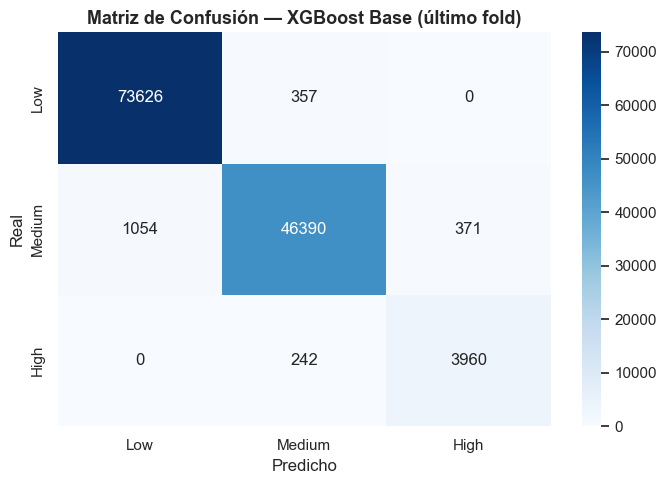


Reporte de clasificación:
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.97      0.98     47815
        High       0.91      0.94      0.93      4202

    accuracy                           0.98    126000
   macro avg       0.96      0.97      0.97    126000
weighted avg       0.98      0.98      0.98    126000



In [5]:
cm = confusion_matrix(last_val_y, last_val_preds)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax
)
ax.set_xlabel("Predicho", fontsize=12)
ax.set_ylabel("Real", fontsize=12)
ax.set_title("Matriz de Confusión — XGBoost Base (último fold)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nReporte de clasificación:")
print(classification_report(last_val_y, last_val_preds, target_names=CLASS_ORDER))

## 4. Tuning — RandomizedSearchCV

In [6]:
param_distributions = {
    "max_depth":        randint(3, 10),
    "learning_rate":    uniform(0.01, 0.29),
    "n_estimators":     randint(100, 801),
    "min_child_weight": randint(1, 10),
    "subsample":        uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma":            uniform(0, 0.5),
}

search_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="accuracy",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y, sample_weight=sample_weights)

best_params    = random_search.best_params_
best_cv_score  = random_search.best_score_

print(f"\n{'='*65}")
print("MEJORES HIPERPARÁMETROS (RandomizedSearchCV)")
print(f"{'='*65}")
for param, val in best_params.items():
    print(f"  {param:25s}: {val}")
print(f"\n  CV Accuracy (mejor): {best_cv_score:.4f}")
print(f"  XGB Base CV Acc:     {np.mean(base_accs):.4f}")
print(f"  Mejora:              {best_cv_score - np.mean(base_accs):+.4f}")
print(f"{'='*65}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

MEJORES HIPERPARÁMETROS (RandomizedSearchCV)
  colsample_bytree         : 0.6488351818802693
  gamma                    : 0.17814891903848745
  learning_rate            : 0.27298024804826865
  max_depth                : 3
  min_child_weight         : 9
  n_estimators             : 382
  subsample                : 0.7708431154505025

  CV Accuracy (mejor): 0.9724
  XGB Base CV Acc:     0.9839
  Mejora:              -0.0115


## 5. Modelo Tuned — Validación CV

In [7]:
tuned_model = XGBClassifier(
    **best_params,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

tuned_accs   = []
tuned_losses = []
last_val_preds_tuned = None
last_val_y_tuned     = None

print(f"{'='*65}")
print("CROSS-VALIDATION — XGBoost Tuned (5-fold)")
print(f"{'='*65}")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y[tr_idx],       y[val_idx]
    sw_tr       = sample_weights[tr_idx]

    tuned_model.fit(X_tr, y_tr, sample_weight=sw_tr, verbose=False)

    proba = tuned_model.predict_proba(X_val)
    preds = np.argmax(proba, axis=1)

    acc = accuracy_score(y_val, preds)
    ll  = log_loss(y_val, proba)
    tuned_accs.append(acc)
    tuned_losses.append(ll)

    last_val_preds_tuned = preds
    last_val_y_tuned     = y_val

    print(f"  Fold {fold}: Accuracy = {acc:.4f}  |  Log-Loss = {ll:.4f}")

print(f"{'='*65}")
print(f"  Tuned — Accuracy: {np.mean(tuned_accs):.4f} ± {np.std(tuned_accs):.4f}")
print(f"  Base  — Accuracy: {np.mean(base_accs):.4f} ± {np.std(base_accs):.4f}")
print(f"  Mejora:           {np.mean(tuned_accs) - np.mean(base_accs):+.4f}")
print(f"{'='*65}")

CROSS-VALIDATION — XGBoost Tuned (5-fold)
  Fold 1: Accuracy = 0.9823  |  Log-Loss = 0.0668
  Fold 2: Accuracy = 0.9820  |  Log-Loss = 0.0684
  Fold 3: Accuracy = 0.9821  |  Log-Loss = 0.0685
  Fold 4: Accuracy = 0.9827  |  Log-Loss = 0.0667
  Fold 5: Accuracy = 0.9825  |  Log-Loss = 0.0667
  Tuned — Accuracy: 0.9823 ± 0.0002
  Base  — Accuracy: 0.9839 ± 0.0002
  Mejora:           -0.0016


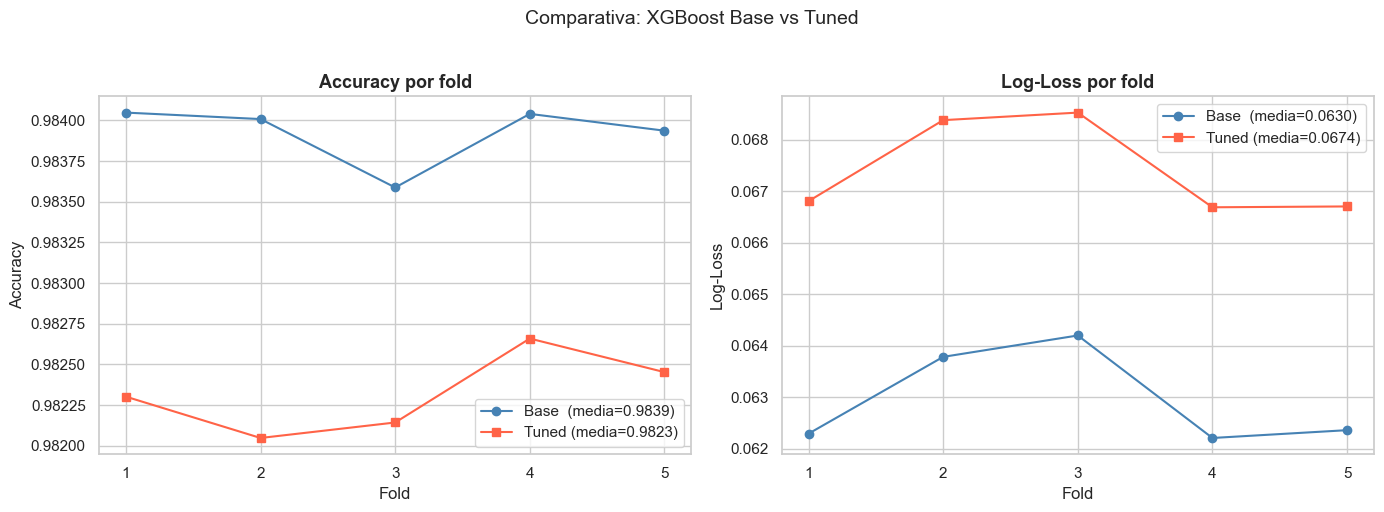

In [8]:
# Comparativa visual Base vs Tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds = np.arange(1, 6)

ax = axes[0]
ax.plot(folds, base_accs,  "o-", color="steelblue",  label=f"Base  (media={np.mean(base_accs):.4f})")
ax.plot(folds, tuned_accs, "s-", color="tomato",     label=f"Tuned (media={np.mean(tuned_accs):.4f})")
ax.set_title("Accuracy por fold", fontsize=13, fontweight="bold")
ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy")
ax.legend(); ax.set_xticks(folds)

ax = axes[1]
ax.plot(folds, base_losses,  "o-", color="steelblue",  label=f"Base  (media={np.mean(base_losses):.4f})")
ax.plot(folds, tuned_losses, "s-", color="tomato",     label=f"Tuned (media={np.mean(tuned_losses):.4f})")
ax.set_title("Log-Loss por fold", fontsize=13, fontweight="bold")
ax.set_xlabel("Fold"); ax.set_ylabel("Log-Loss")
ax.legend(); ax.set_xticks(folds)

plt.suptitle("Comparativa: XGBoost Base vs Tuned", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Feature Importance

FEATURE IMPORTANCE (Gain) — XGBoost Tuned
  Crop_Growth_Stage                  : 0.2293  █████████████████████████████████████████████
  Mulching_Used                      : 0.2217  ████████████████████████████████████████████
  Soil_Moisture                      : 0.1874  █████████████████████████████████████
  Wind_Speed_kmh                     : 0.1255  █████████████████████████
  Temperature_C                      : 0.1236  ████████████████████████
  Rainfall_mm                        : 0.0546  ██████████
  Previous_Irrigation_mm             : 0.0061  █
  Water_Source                       : 0.0053  █
  Electrical_Conductivity            : 0.0052  █
  Humidity                           : 0.0051  █
  Irrigation_Type                    : 0.0049  
  Soil_pH                            : 0.0048  
  Organic_Carbon                     : 0.0044  
  Sunlight_Hours                     : 0.0041  
  Soil_Type                          : 0.0040  
  Crop_Type                          : 0.0039  
 

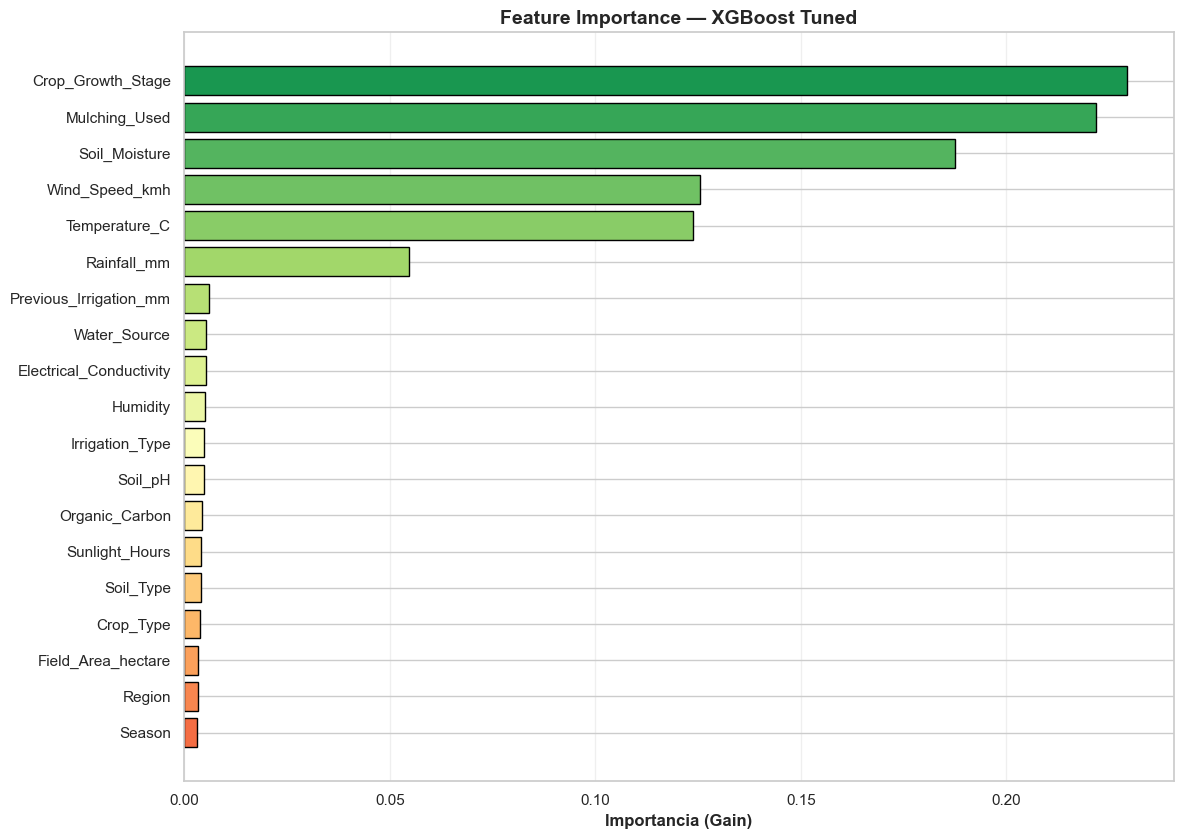

In [9]:
# Entrenar el modelo tuned sobre todo el train
tuned_model.fit(X_train, y, sample_weight=sample_weights, verbose=False)

importances = tuned_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

print(f"{'='*65}")
print("FEATURE IMPORTANCE (Gain) — XGBoost Tuned")
print(f"{'='*65}")
for feat, imp in feat_imp.sort_values(ascending=False).items():
    bar = "█" * int(imp * 200)
    print(f"  {feat:35s}: {imp:.4f}  {bar}")
print(f"{'='*65}")

colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
plt.figure(figsize=(12, max(5, len(feat_imp) * 0.45)))
plt.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor="black")
plt.xlabel("Importancia (Gain)", fontsize=12, fontweight="bold")
plt.title("Feature Importance — XGBoost Tuned", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 7. Predicciones y Submission

PREDICCIONES SOBRE TEST
Registros: 270,000

Distribución predicha:
  Low     : 159,924  (59.23%)
  Medium  :  99,949  (37.02%)
  High    :  10,127  (3.75%)


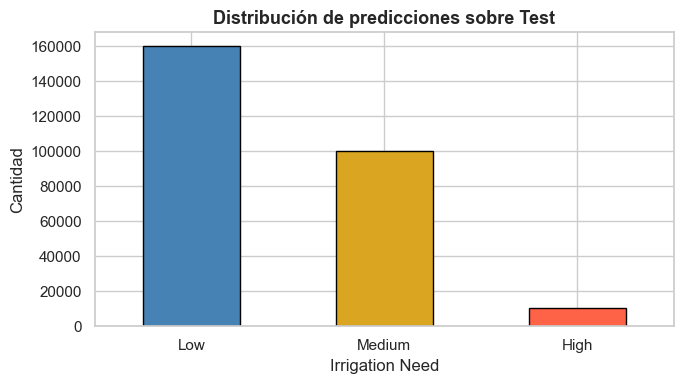

In [10]:
# Predecir sobre test (el modelo ya está entrenado en todo train)
test_proba = tuned_model.predict_proba(X_test)
test_preds = np.argmax(test_proba, axis=1)
test_labels = [INV_MAP[i] for i in test_preds]

print(f"{'='*65}")
print("PREDICCIONES SOBRE TEST")
print(f"{'='*65}")
print(f"Registros: {len(test_labels):,}")
print(f"\nDistribución predicha:")
pred_counts = pd.Series(test_labels).value_counts().reindex(["Low", "Medium", "High"])
for cls, cnt in pred_counts.items():
    print(f"  {cls:8s}: {cnt:>7,}  ({cnt/len(test_labels)*100:.2f}%)")
print(f"{'='*65}")

fig, ax = plt.subplots(figsize=(7, 4))
palette = {"Low": "steelblue", "Medium": "goldenrod", "High": "tomato"}
pred_counts.plot.bar(ax=ax, color=[palette[c] for c in pred_counts.index], edgecolor="black")
ax.set_title("Distribución de predicciones sobre Test", fontsize=13, fontweight="bold")
ax.set_ylabel("Cantidad")
ax.set_xlabel("Irrigation Need")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
import os

submission = pd.DataFrame({
    "id":           ids_test,
    TARGET:         test_labels
})

submission_path = "../data/2_XGB_submission.csv"
submission.to_csv(submission_path, index=False)

print(f"{'='*65}")
print("SUBMISSION GENERADA")
print(f"{'='*65}")
print(f"Archivo:  {os.path.abspath(submission_path)}")
print(f"Filas:    {len(submission):,}")
print(f"Columnas: {list(submission.columns)}")
print(f"\nPrimeras filas:")
print(submission.head(5).to_string(index=False))
print(f"\n--- Resumen de modelos ---")
print(f"  XGB Base  — Accuracy: {np.mean(base_accs):.4f} ± {np.std(base_accs):.4f}")
print(f"  XGB Tuned — Accuracy: {np.mean(tuned_accs):.4f} ± {np.std(tuned_accs):.4f}")
print(f"{'='*65}")

SUBMISSION GENERADA
Archivo:  c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\DGKaggle\Playground Series\Season 6\Episode 4 - Predicting Irrigation Need\data\2_XGB_submission.csv
Filas:    270,000
Columnas: ['id', 'Irrigation_Need']

Primeras filas:
    id Irrigation_Need
630000             Low
630001             Low
630002             Low
630003             Low
630004             Low

--- Resumen de modelos ---
  XGB Base  — Accuracy: 0.9839 ± 0.0002
  XGB Tuned — Accuracy: 0.9823 ± 0.0002


## 8. Envío a Kaggle

In [12]:
import sys
!{sys.executable} -m pip install --upgrade kaggle --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
COMPETITION = "playground-series-s6e4"
FILE        = "../data/2_XGB_submission.csv"
MSG         = f"XGBoost multiclase tuned - todas las variables - Acc={np.mean(tuned_accs):.4f}"

!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

Successfully submitted to Predicting Irrigation Need



  0%|          | 0.00/3.39M [00:00<?, ?B/s]
  0%|          | 16.0k/3.39M [00:00<00:49, 71.4kB/s]
  4%|▍         | 144k/3.39M [00:00<00:07, 474kB/s]  
 15%|█▌        | 528k/3.39M [00:00<00:03, 805kB/s]
 18%|█▊        | 640k/3.39M [00:00<00:03, 830kB/s]
 61%|██████    | 2.06M/3.39M [00:00<00:00, 3.75MB/s]
100%|██████████| 3.39M/3.39M [00:02<00:00, 1.74MB/s]
